# 02 - La finestra de món petit ($L$ i $C$ vs $\beta$ i $k$)

En aquest notebook fem un anàlisi ràpid de les dues mètriques estructurals esmentades a l'enunciat:

* **$L$** — camí mig (mitjana de les distàncies mínimes entre tots els parells de nodes).
* **$C$** — coeficient de clusterització (proporció de camins de longitud 2 que tanquen en triangle).

L'objectiu és veure el **fenomen del món petit**: partint de l'anell regular ($\beta=0$) i
reconnectant arestes amb probabilitat $\beta$, hi ha una finestra (≈ $\beta \in [10^{-2}, 10^{-1}]$)
on $L$ ja ha caigut a valors d'una xarxa aleatòria però $C$ encara és alta com a l'anell.

In [1]:
%load_ext autoreload
%autoreload 2

import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np

from src.smallworld.visualization import compute_metrics_data

## 1. Paràmetres i dades

Definim els paràmetres a utilitzar per l'experiment (exactament els mateixos que els de la documentació web).

In [2]:
N        = 1000
K_VALUES = list(range(10, 101, 10))          # 10, 20, ..., 100
BETAS    = [0.0001, 0.001, 0.01, 0.1, 1.0]   # escala log
SEED     = 42
K_DEFAULT = 10                               # k que la doc obre per defecte

CACHE = ROOT / "data" / "metrics_analytics_data.json"
if CACHE.exists():
    with open(CACHE, encoding="utf-8") as fh:
        data = json.load(fh)
    print(f"Dades carregades de la cache de la documentació: {CACHE.relative_to(ROOT)}")
else:
    print("Cache no trobada; recalculant amb seed=42 (pot trigar 1-3 min)...")
    data = compute_metrics_data(N=N, k_values=K_VALUES, betas=BETAS, seed=SEED)


def ws_metric(k, beta, metric):
    """L o C de la WS(N, k, beta) tal com es guarda a la cache."""
    return data[str(k)]["ws"][f"{beta:g}"][metric]

Dades carregades de la cache de la documentació: data\metrics_analytics_data.json


## 2. La finestra de món petit per a un $k$ fix

Agafem $k=10$ (el valor per defecte de la doc). Calculem $L(\beta)$ i $C(\beta)$ i els
normalitzem pel valor a l'anell ($\beta=0$), després els dibuixem junts en escala log-$\beta$.

In [3]:
k = K_DEFAULT

# Referència: anell regular (beta = 0)
L0 = data[str(k)]["ring"]["L"]
C0 = data[str(k)]["ring"]["C"]
print(f"Anell regular (beta=0):  L0 = {L0:.3f},  C0 = {C0:.3f}\n")

L_norm, C_norm = [], []
for beta in BETAS:
    L = ws_metric(k, beta, "L")
    C = ws_metric(k, beta, "C")
    L_norm.append(L / L0)
    C_norm.append(C / C0)
    print(f"beta={beta:<7} L={L:7.3f} (L/L0={L/L0:.3f})   C={C:.3f} (C/C0={C/C0:.3f})")

Anell regular (beta=0):  L0 = 50.450,  C0 = 0.667

beta=0.0001  L= 38.499 (L/L0=0.763)   C=0.666 (C/C0=1.000)
beta=0.001   L= 33.854 (L/L0=0.671)   C=0.666 (C/C0=0.999)
beta=0.01    L=  9.387 (L/L0=0.186)   C=0.647 (C/C0=0.971)
beta=0.1     L=  4.472 (L/L0=0.089)   C=0.488 (C/C0=0.732)
beta=1.0     L=  3.271 (L/L0=0.065)   C=0.009 (C/C0=0.013)


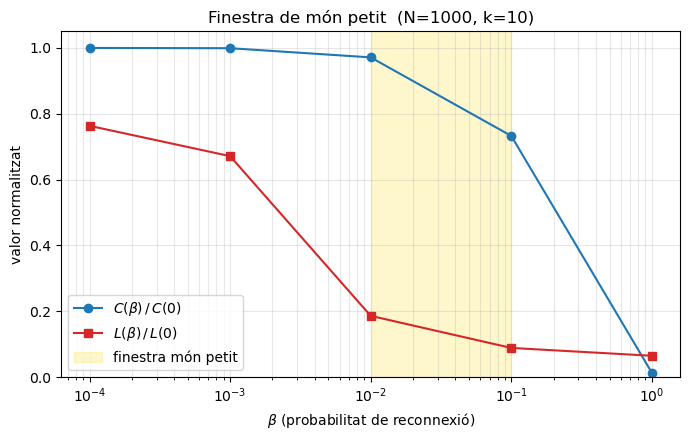

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(BETAS, C_norm, "o-", color="#1f77b4", label=r"$C(\beta)\,/\,C(0)$")
ax.plot(BETAS, L_norm, "s-", color="#d62728", label=r"$L(\beta)\,/\,L(0)$")

# Banda que ressalta la finestra de món petit
ax.axvspan(0.01, 0.1, color="gold", alpha=0.2, label="finestra món petit")

ax.set_xscale("log")
ax.set_xlabel(r"$\beta$ (probabilitat de reconnexió)")
ax.set_ylabel("valor normalitzat")
ax.set_title(f"Finestra de món petit  (N={N}, k={k})")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, which="both", alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES / "02_small_world_window.png", dpi=150)
plt.show()

**Lectura del gràfic.** $L(\beta)/L(0)$ (vermell) cau gairebé en vertical cap a $\beta \approx 10^{-2}$:
amb molt poques reconnexions aleatòries ja n'hi ha prou per escurçar dràsticament les distàncies.
En canvi $C(\beta)/C(0)$ (blau) es manté alt fins a $\beta \approx 10^{-1}$, perquè reconnectar
una aresta només trenca uns pocs triangles locals. La separació entre les dues corbes
(zona daurada) és exactament el **règim de món petit**: distàncies curtes + clusterització alta.

## 3. Efecte de diferents $k$

Repetim el procés per a $k \in \{10, 20, \dots, 100\}$.
Així comprovem si la finestra és robusta o depèn del nombre de veïns.

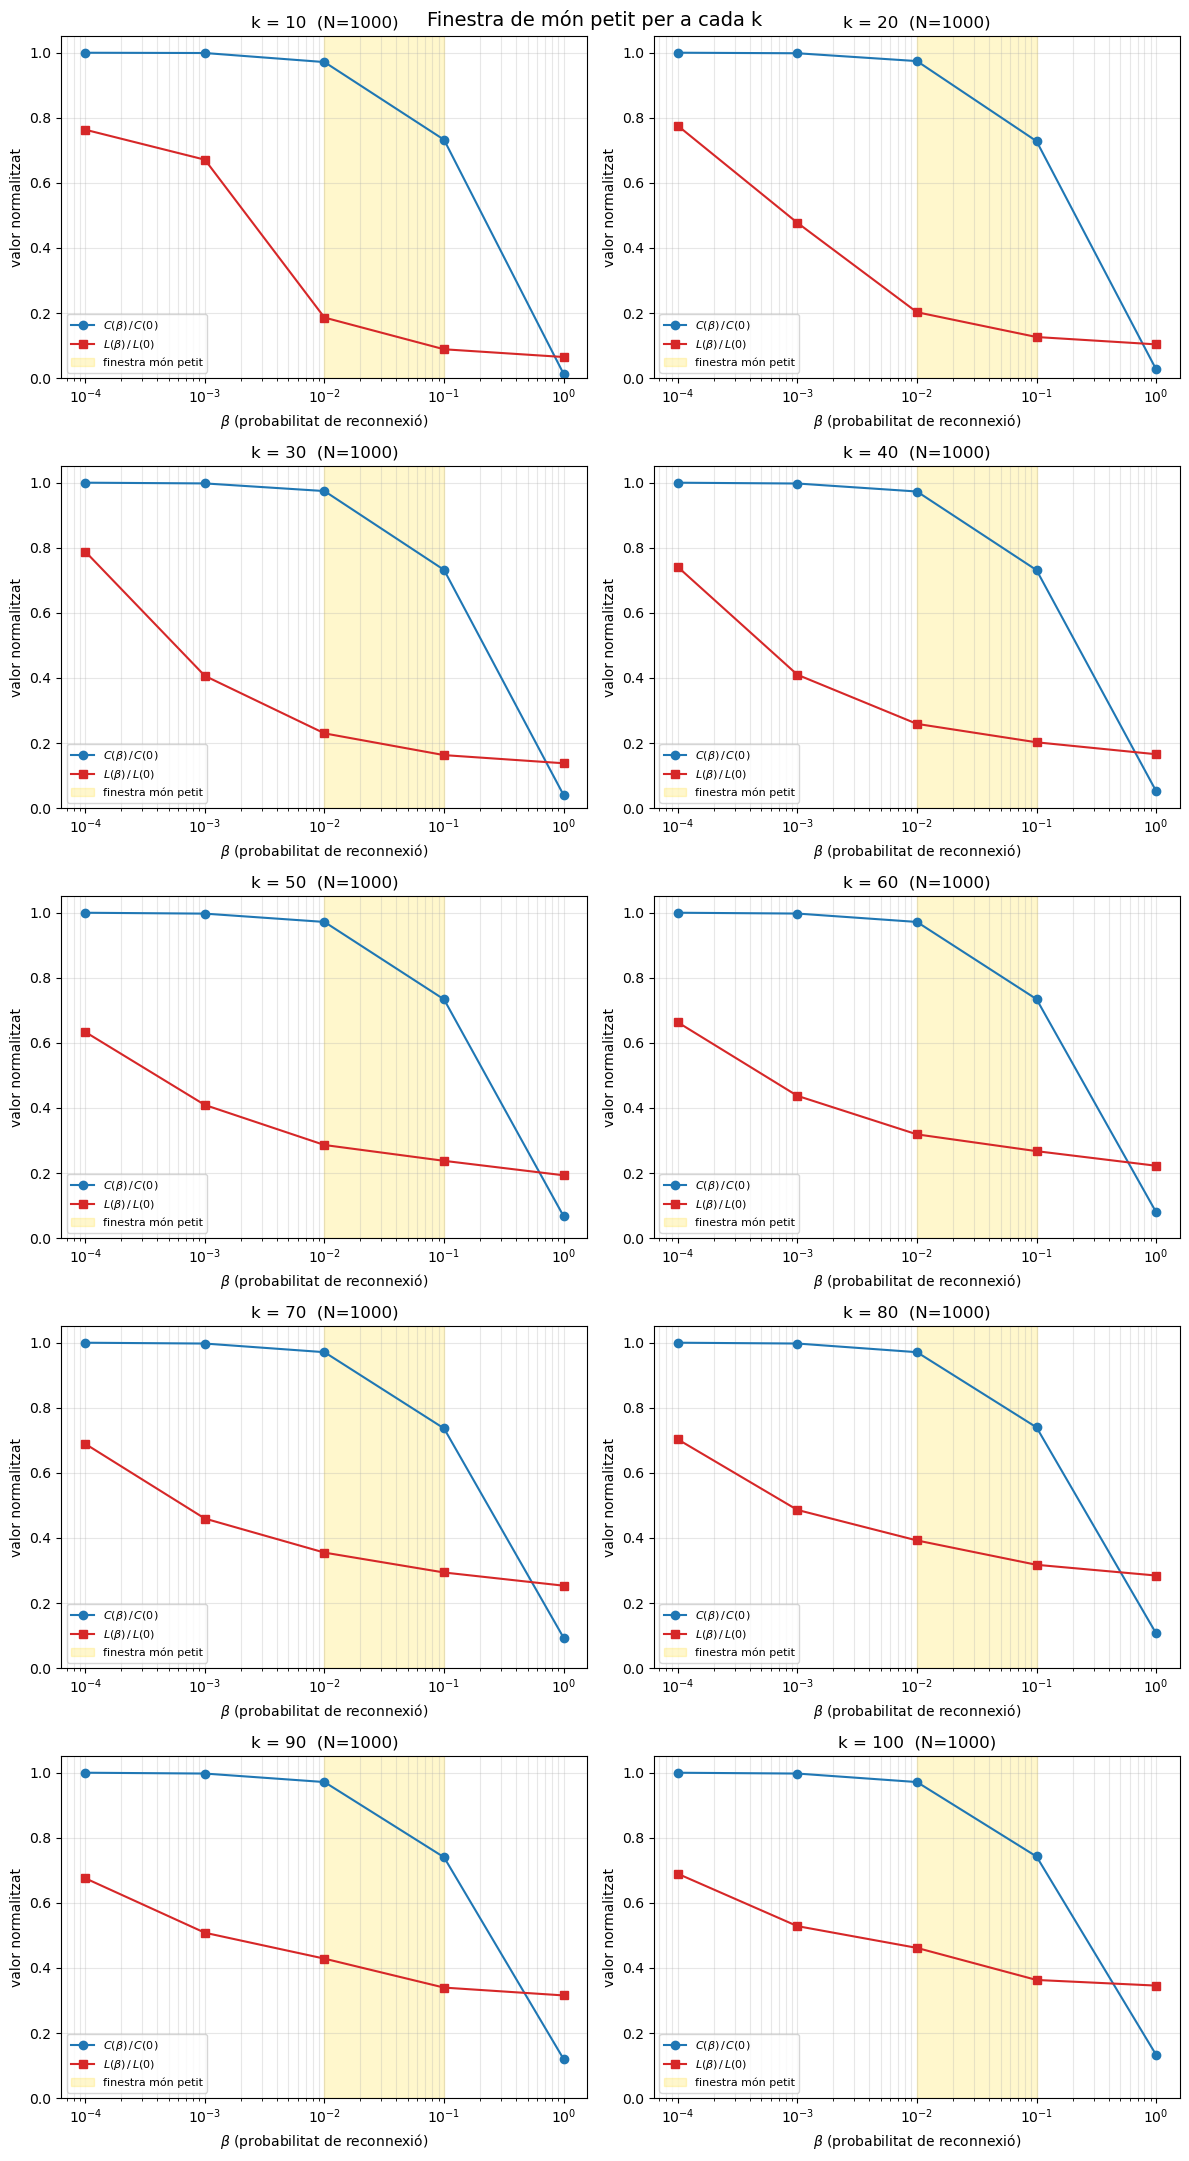

In [5]:
fig, axes = plt.subplots(5, 2, figsize=(12, 22))

for ax, kk in zip(axes.flat, K_VALUES):
    L0k = data[str(kk)]["ring"]["L"]
    C0k = data[str(kk)]["ring"]["C"]
    L_norm_k = [ws_metric(kk, b, "L") / L0k for b in BETAS]
    C_norm_k = [ws_metric(kk, b, "C") / C0k for b in BETAS]

    ax.plot(BETAS, C_norm_k, "o-", color="#1f77b4", label=r"$C(\beta)\,/\,C(0)$")
    ax.plot(BETAS, L_norm_k, "s-", color="#d62728", label=r"$L(\beta)\,/\,L(0)$")

    # Banda que ressalta la finestra de món petit
    ax.axvspan(0.01, 0.1, color="gold", alpha=0.2, label="finestra món petit")

    ax.set_xscale("log")
    ax.set_xlabel(r"$\beta$ (probabilitat de reconnexió)")
    ax.set_ylabel("valor normalitzat")
    ax.set_title(f"k = {kk}  (N={N})")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)

fig.suptitle("Finestra de món petit per a cada k", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES / "02_window_per_k.png", dpi=150)
plt.show()

**Lectura.** Tot i que $C(\beta)/C(0)$ gairebé no varia amb $k$, i $L(\beta)/L(0)$ sí que canvia una mica de comportament —és lògic esperar que la distància mitjana entre parells de nodes caigui com més veïns té cada node—, el **fenomen del món petit es manté independentment de $k$**: en tots els subgràfics $C$ aguanta a prop d'1 mentre $L$ ja ha començat a caure, de manera que la diferència relativa entre les dues mètriques (la finestra daurada) hi apareix sempre.

## 4. Comparativa de les tres xarxes

Finalment, posem costat a costat l'anell regular, la Watts–Strogatz amb $\beta=0.1$ (fenomen del món petit) i l'Erdős–Rényi, totes amb $N=1000$ i $k=10$.

In [6]:
k = K_DEFAULT
rows = {
    "Anell regular (beta=0)":     (data[str(k)]["ring"]["L"], data[str(k)]["ring"]["C"]),
    "Watts-Strogatz (beta=0.1)":  (ws_metric(k, 0.1, "L"),    ws_metric(k, 0.1, "C")),
    "Erdos-Renyi":                (data[str(k)]["er"]["L"],   data[str(k)]["er"]["C"]),
}

print(f"{'Xarxa':<28}{'L':>8}{'C':>8}")
print("-" * 44)
for name, (L, C) in rows.items():
    print(f"{name:<28}{L:>8.3f}{C:>8.3f}")

Xarxa                              L       C
--------------------------------------------
Anell regular (beta=0)        50.450   0.667
Watts-Strogatz (beta=0.1)      4.472   0.488
Erdos-Renyi                    3.259   0.011


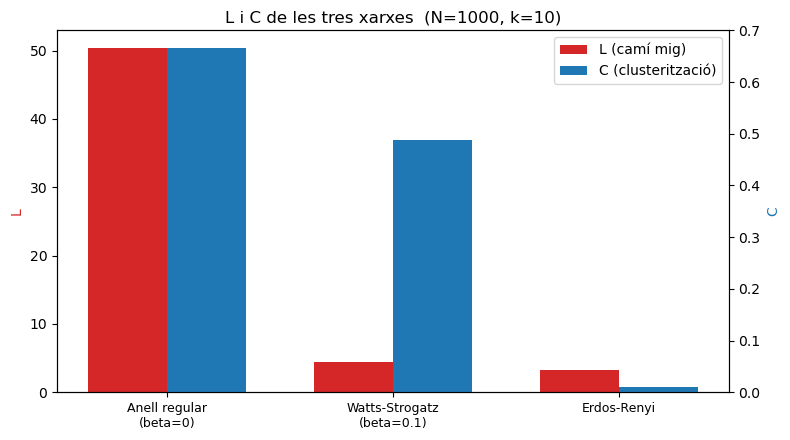

In [7]:
names = list(rows.keys())
Ls = [rows[n][0] for n in names]
Cs = [rows[n][1] for n in names]
x = np.arange(len(names))
w = 0.35

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax2 = ax1.twinx()
ax1.bar(x - w / 2, Ls, w, color="#d62728", label="L (camí mig)")
ax2.bar(x + w / 2, Cs, w, color="#1f77b4", label="C (clusterització)")

ax1.set_ylabel("L", color="#d62728")
ax2.set_ylabel("C", color="#1f77b4")
ax1.set_xticks(x)
ax1.set_xticklabels([n.replace(" (", "\n(") for n in names], fontsize=9)
ax1.set_title(f"L i C de les tres xarxes  (N={N}, k={k})")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")

fig.tight_layout()
fig.savefig(FIGURES / "02_three_networks_LC.png", dpi=150)
plt.show()

## 5. Conclusions

- **L cau molt abans que C.** N'hi ha prou amb $\beta \approx 10^{-2}$ (poques reconnexions
  aleatòries) per reduir el camí mig gairebé al d'una xarxa aleatòria, mentre que la
  clusterització no comença a baixar de debò fins a $\beta \approx 10^{-1}$.
- **La finestra de món petit** ($\beta \in [10^{-2}, 10^{-1}]$) és la zona on coexisteixen
  $L$ petita (com Erdős–Rényi) i $C$ alta (com l'anell).
- **És robust en $k$.** El comportament es repeteix per a tots els $k \in \{10,\dots,100\}$;
  augmentar $k$ només fa la finestra una mica més ampla, sense canviar-ne la natura.
- **Les tres xarxes** confirmen els valors teòrics: l'anell té $L$ gran i $C$ gran,
  l'Erdős–Rényi té $L$ petita i $C$ gairebé nul·la, i la Watts–Strogatz dins la finestra
  combina el millor dels dos móns.